# Car Price Prediction: End-to-End ML Project

**Problem Statement:** Build an ML regression pipeline to automate vehicle valuation (MSRP) based on brand, age, and specifications to optimize dealership pricing and protect profit margins.
> **Dataset :** Car Features and MSRP · 11,914 cars · 16 features  

> **Target   :** MSRP (Manufacturer Suggested Retail Price)  

> **Approach :** Compare Linear Regression, Random Forest and XGBoost  

### 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')

### 2. Reading Data


In [2]:
df = pd.read_csv("data\car_price_prediction.csv")

In [3]:
df.head(10)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
5,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,31200
6,BMW,1 Series,2012,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,26,17,3916,44100
7,BMW,1 Series,2012,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,39300
8,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,36900
9,BMW,1 Series,2013,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,27,18,3916,37200


In [4]:
df.shape

(11914, 16)

In [5]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

### 3. Cleaning Columns and Text formatting


In [6]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

string_columns = df.select_dtypes(include="object").columns

for col in string_columns:
    df[col] = df[col].str.lower().str.replace(" ", "_")

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [8]:
df.describe()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


##### Duplicate checks

In [9]:
df.duplicated().sum()

np.int64(715)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(11199, 16)

##### Handling Missing Values

In [12]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3376
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [13]:
df["market_category"].value_counts()

market_category
crossover                                          1075
flex_fuel                                           855
luxury                                              819
luxury,performance                                  659
hatchback                                           574
                                                   ... 
crossover,exotic,luxury,high-performance              1
crossover,exotic,luxury,performance                   1
exotic,luxury,high-performance,hybrid                 1
flex_fuel,factory_tuner,luxury,high-performance       1
performance,hybrid                                    1
Name: count, Length: 71, dtype: int64

In [15]:
df.drop(columns = "market_category", inplace = True)

In [16]:
df["engine_hp"] = df["engine_hp"].fillna(df["engine_hp"].median())
df["engine_cylinders"] = df["engine_cylinders"].fillna(df["engine_cylinders"].median())
df["number_of_doors"] = df["number_of_doors"].fillna(df["number_of_doors"].mode()[0])
df["engine_fuel_type"] = df["engine_fuel_type"].fillna(df["engine_fuel_type"].mode()[0])

In [17]:
for col in df.columns:
    print(col)
    print(df[col].head())
    print()

make
0    bmw
1    bmw
2    bmw
3    bmw
4    bmw
Name: make, dtype: str

model
0    1_series_m
1      1_series
2      1_series
3      1_series
4      1_series
Name: model, dtype: str

year
0    2011
1    2011
2    2011
3    2011
4    2011
Name: year, dtype: int64

engine_fuel_type
0    premium_unleaded_(required)
1    premium_unleaded_(required)
2    premium_unleaded_(required)
3    premium_unleaded_(required)
4    premium_unleaded_(required)
Name: engine_fuel_type, dtype: str

engine_hp
0    335.0
1    300.0
2    300.0
3    230.0
4    230.0
Name: engine_hp, dtype: float64

engine_cylinders
0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
Name: engine_cylinders, dtype: float64

transmission_type
0    manual
1    manual
2    manual
3    manual
4    manual
Name: transmission_type, dtype: str

driven_wheels
0    rear_wheel_drive
1    rear_wheel_drive
2    rear_wheel_drive
3    rear_wheel_drive
4    rear_wheel_drive
Name: driven_wheels, dtype: str

number_of_doors
0    2.0
1    2.0
2    2.0
3

In [18]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[2. 4. 3.]
3

vehicle_size
<StringArray>
['compact', 'midsize', 'large']
Length: 3, dtype: str
3

vehicle_style
<StringArray>
['coupe', 'convertible', 'sedan', 'wago

##### Global Shuffle

In [19]:
n = len(df)

In [20]:
idx = np.arange(n)

In [21]:
np.random.seed(2)
np.random.shuffle(idx)

In [22]:
df = df.iloc[idx].reset_index(drop = True)

In [23]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,audi,r8,2015,premium_unleaded_(required),525.0,10.0,automated_manual,all_wheel_drive,2.0,compact,convertible,22,13,3105,175100
1,mazda,rx-8,2010,premium_unleaded_(required),232.0,6.0,manual,rear_wheel_drive,4.0,compact,coupe,22,16,586,32110
2,toyota,sequoia,2015,regular_unleaded,381.0,8.0,automatic,rear_wheel_drive,4.0,large,4dr_suv,17,13,2031,61095
3,infiniti,m35,2010,premium_unleaded_(recommended),303.0,6.0,automatic,all_wheel_drive,4.0,large,sedan,22,16,190,47950
4,ford,edge,2016,premium_unleaded_(recommended),245.0,4.0,automatic,front_wheel_drive,4.0,midsize,4dr_suv,30,20,5657,28700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11194,audi,a8,2017,premium_unleaded_(required),450.0,8.0,automatic,all_wheel_drive,4.0,large,sedan,29,18,3105,91500
11195,chevrolet,c/k_2500_series,1998,regular_unleaded,230.0,8.0,manual,rear_wheel_drive,2.0,large,regular_cab_pickup,17,13,1385,2697
11196,mazda,mpv,2006,regular_unleaded,200.0,6.0,automatic,front_wheel_drive,4.0,compact,passenger_minivan,23,16,586,22115
11197,mercedes-benz,cls-class,2016,premium_unleaded_(required),402.0,8.0,automatic,rear_wheel_drive,4.0,midsize,sedan,26,17,617,74100


### 4. Exploratory Data Analysis (EDA)

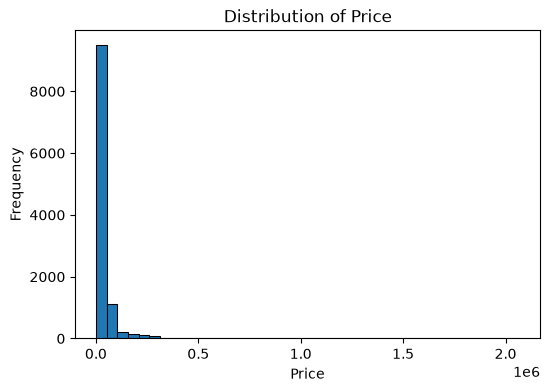

Skewness  raw    : 11.61


In [24]:
plt.figure(figsize = (6,4))   # Price Distribution Plots

sns.histplot(df.msrp, bins = 40, alpha = 1)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")

plt.show()

sk_raw = df['msrp'].skew()
print(f'Skewness  raw    : {sk_raw:.2f}')

The MSRP distribution is highly **right-skewed**, with a few extremely expensive cars stretching the distribution and creating significant outliers. The presence of extreme outliers suggests that the models trained on raw dollars will heavily prioritize rare supercars over standard vehicles and we may need to investigate them further or consider a log transformation of the target variable when modeling.

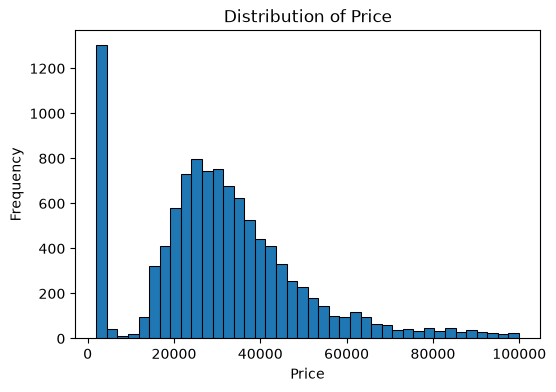

In [25]:
plt.figure(figsize = (6,4))   # Price distribution under $100k

sns.histplot(df.msrp[df.msrp < 100000], bins = 40, alpha = 1)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")

plt.show()

After excluding prices above $100,000, most cars are concentrated between $20,000 and $40,000, representing our primary consumer transaction segment, with the distribution remaining slightly right-skewed. The sharp spike below $10000 represents budget/older vehicles, where depreciation has bottomed out, meaning their pricing is driven heavily by vehicle condition and age rather than brand prestige.

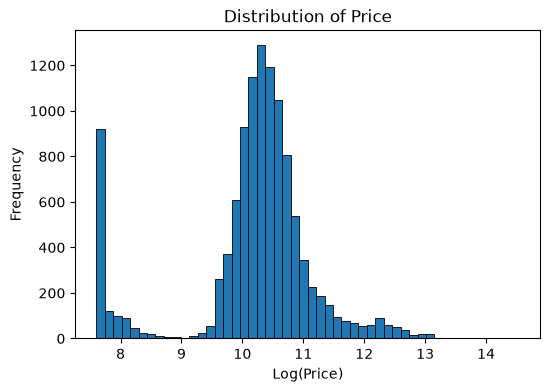

Skewness  log1p  : -0.93


In [26]:
msrp_logs = np.log1p(df.msrp)

plt.figure(figsize = (6,4))

sns.histplot(msrp_logs, bins = 50, alpha = 1)

plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.title("Distribution of Price")

plt.show()

sk_log = msrp_logs.skew()
print(f'Skewness  log1p  : {sk_log:.2f}')

* **Normalization:** Log transformation successfully reduced skewness from **11.61** to **-0.93**, creating a much more stable, near-normal distribution.
* **Model Benefit:** This bell-curve distribution prevents high-priced outliers from dominating the training, allowing regression models to learn pricing patterns reliably.
* **The 7.6 Peak:** The spike on the far left represents the $2,000 budget pricing floor present in the raw data.

In [27]:
df.corr(numeric_only = True)  # Correlation Heatmap

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
year,1.000000,0.335238,-0.034152,0.247739,0.244972,0.188417,0.085874,0.209635
engine_hp,0.335238,1.000000,0.773664,-0.129217,-0.362952,-0.355036,0.041947,0.658693
engine_cylinders,-0.034152,0.773664,1.000000,-0.149798,-0.596246,-0.562599,0.038325,0.538531
number_of_doors,0.247739,-0.129217,-0.149798,1.000000,0.115081,0.121013,-0.057213,-0.144353
highway_mpg,0.244972,-0.362952,-0.596246,0.115081,1.000000,0.886299,-0.017159,-0.166631
city_mpg,0.188417,-0.355036,-0.562599,0.121013,0.886299,1.000000,-0.000549,-0.162343
popularity,0.085874,0.041947,0.038325,-0.057213,-0.017159,-0.000549,1.000000,-0.048371
msrp,0.209635,0.658693,0.538531,-0.144353,-0.166631,-0.162343,-0.048371,1.000000


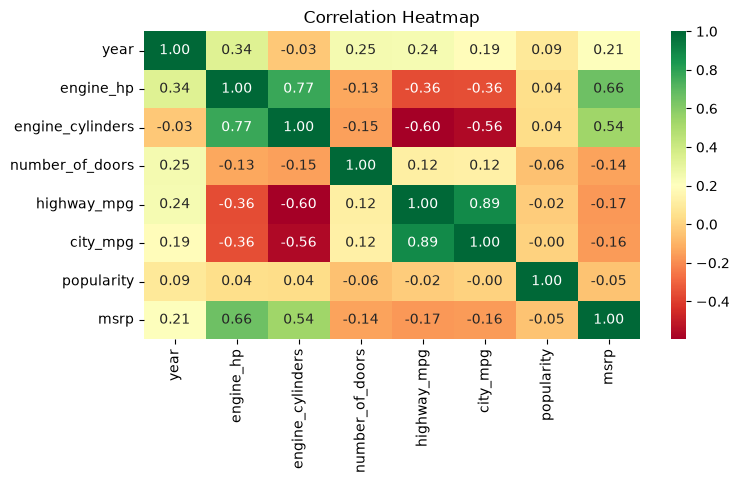

In [28]:
plt.figure(figsize = (8,4))

sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "RdYlGn", fmt = ".2f")
plt.title("Correlation Heatmap")

plt.show()

Observations

1. `engine_hp` has the strongest positive correlation with MSRP (0.66), indicating that more powerful cars tend to be more expensive.
2. `engine_cylinders` also shows a moderate positive relationship with MSRP (0.54).
3. `year` has a weak positive correlation with price (0.21), suggesting newer cars are generally more expensive.
4. `highway_mpg` and `city_mpg` have a very high correlation (0.89), indicating potential multicollinearity.
5. `engine_hp` and `engine_cylinders` are also highly correlated (0.79).
6. `popularity` has almost no linear relationship with MSRP (-0.05).


Feature Engineering-
1. **Calculate Vehicle Age:** 
   Although manufacturing `year` has a moderate correlation (0.21) with MSRP, calendar years are less intuitive for models. We should create a new `age` feature (`2017 - year`) in the next section to represent depreciation more directly.
2. **Address Performance vs. Efficiency Trade-off:**
   The heatmap shows a strong negative correlation (up to -0.60) between performance (`engine_hp` / `engine_cylinders`) and fuel economy (`highway_mpg` / `city_mpg`). We should explore creating a combined "Power-to-Economy" interaction feature later to capture how efficiently an engine delivers its power.


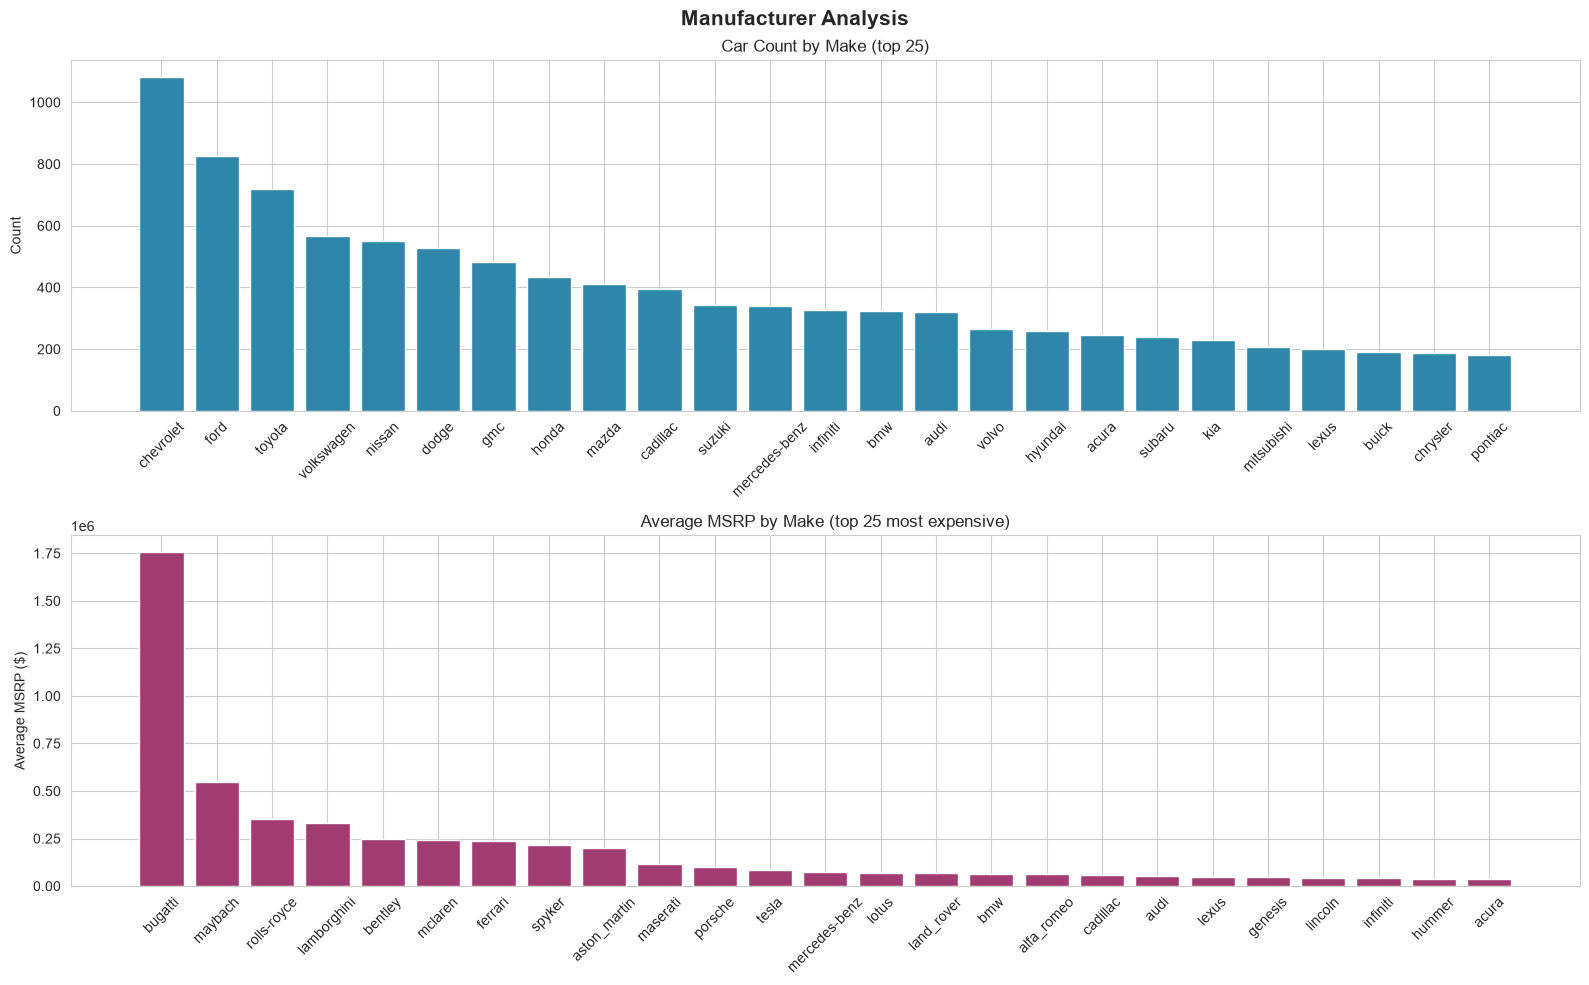

In [29]:
sns.set_style("whitegrid") 
fig, axes = plt.subplots(2, 1, figsize = (16, 10))
fig.suptitle('Manufacturer Analysis', fontsize = 15, fontweight='bold')

# Volume
counts = df['make'].value_counts().head(25)

axes[0].bar(counts.index, counts.values, color = '#2E86AB')

axes[0].set_title('Car Count by Make (top 25)')
axes[0].set_xticklabels(counts.index, rotation = 45)
axes[0].set_ylabel('Count')

# Average price
avg_p = df.groupby('make')['msrp'].mean().sort_values(ascending=False).head(25)
bars = axes[1].bar(avg_p.index, avg_p.values, color = '#A23B72')

axes[1].set_title('Average MSRP by Make (top 25 most expensive)')
axes[1].set_xticklabels(avg_p.index, rotation = 45)
axes[1].set_ylabel('Average MSRP ($)')

plt.tight_layout()
plt.show()

Chevrolet, Ford, Toyota, Volkswagen, and Nissan have the highest number of vehicles in the dataset. 

Luxury manufacturers such as Bugatti, Maybach, Rolls-Royce, and Lamborghini have the highest average MSRP, whereas mainstream brands have considerably lower average prices.

Manufacturer appears to be an important predictor of vehicle price and therefore require categorical encoding before modeling.
The dataset is imbalanced across manufacturers, which may influence the model's learning for brands with limited data.

Exotic Volume Discrepancy: The most expensive brand (Bugatti, averaging $1.75M+) has almost zero volume in the dataset. Because the model has so few examples of these rare brands to learn from, predictions on exotics will be highly unstable compared to high-volume brands like Chevrolet or Ford.

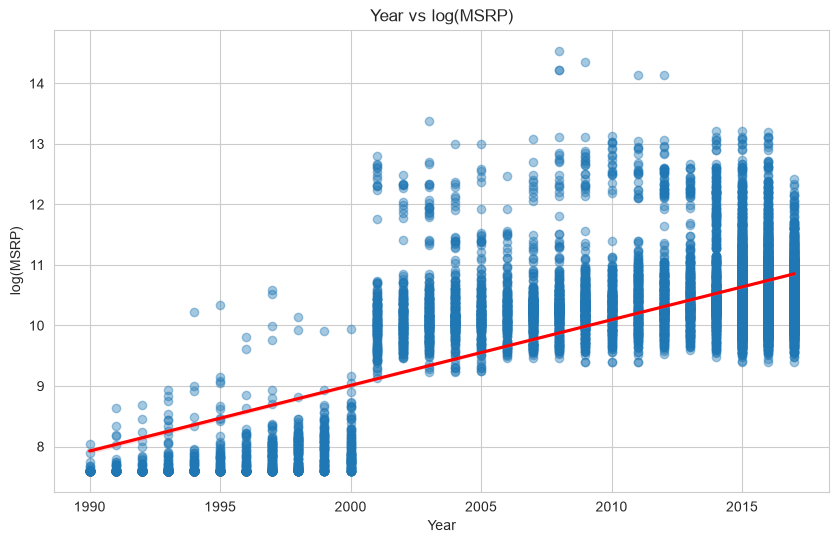

In [30]:
plt.figure(figsize = (10, 6))

sns.regplot(data = df, x = 'year', y = msrp_logs, scatter_kws = {'alpha': 0.4}, line_kws = {'color': 'red'}) 

plt.xlabel("Year")
plt.ylabel("log(MSRP)")
plt.title("Year vs log(MSRP)")

plt.show()

Newer vehicles tend to have higher prices, but the relationship is relatively weak and there is substantial variation in MSRP within the same manufacturing year.
Manufacturing year alone is not sufficient to explain vehicle price; other features such as brand and engine specifications are also important.

Car prices have increased consistently over the past 3 decades, reflecting inflation and market evolution. The dataset is right-heavy (2000–2017), which means our model will predict modern car prices more reliably than vintage car prices.

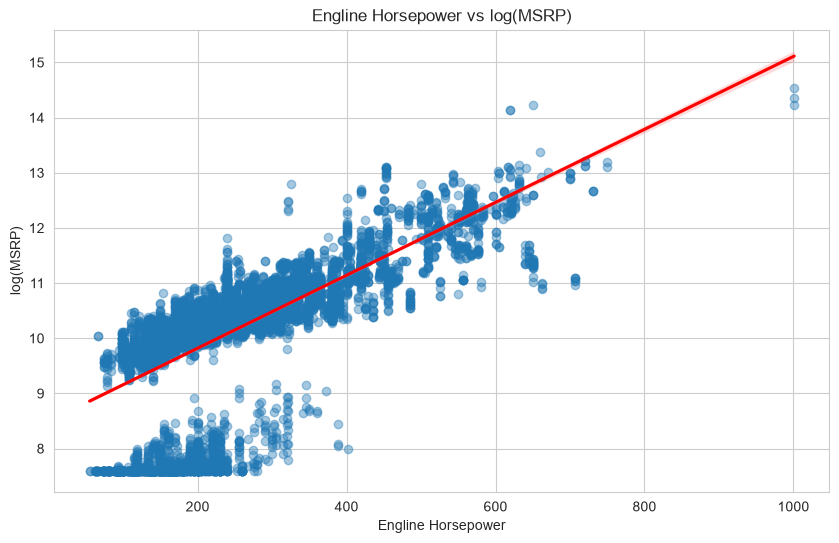

In [31]:
plt.figure(figsize = (10,6))

sns.regplot(data = df, x = 'engine_hp', y = msrp_logs, scatter_kws = {'alpha': 0.4}, line_kws = {'color': 'red'})

plt.xlabel("Engline Horsepower")
plt.ylabel("log(MSRP)")
plt.title("Engline Horsepower vs log(MSRP)")

plt.show()

MSRP generally increases with engine horsepower, indicating a strong positive relationship, although a few high-priced outliers are present.

Engine horsepower is the single strongest predictor of car price in this dataset, showing a clear, near-linear relationship on the log scale. 

The $2,000 Price Floor Cluster: There is a distinct horizontal cluster at the bottom left (around log(MSRP) = 7.6) stretching from 100 HP to about 400 HP. This shows that for extremely cheap or salvage vehicles, horsepower has no impact on price—they all flatline at the absolute market floor value.

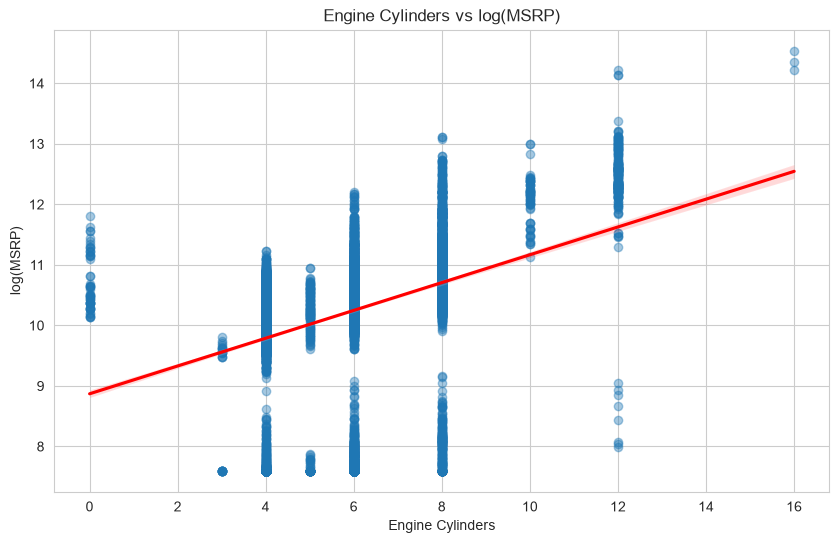

In [32]:
plt.figure(figsize = (10,6))

sns.regplot(data = df, x = 'engine_cylinders', y = msrp_logs, scatter_kws = {'alpha': 0.4}, line_kws = {'color': 'red'})

plt.xlabel("Engine Cylinders")
plt.ylabel("log(MSRP)")
plt.title("Engine Cylinders vs log(MSRP)")

plt.show()

While more cylinders generally signals a higher price, the relationship has significant spread within each cylinder group. A 4-cylinder economy car ($15,000) and a 4−cylinder sports car ($80,000) both appear in the same column. This suggests engine cylinders is a useful but incomplete predictor on its own.

Within each cylinder count there is very high vertical spread, meaning cylinders alone don't fully determine price- brand and luxury level matter a lot too.

The 0-Cylinder Cluster (EVs): Note the cluster of cars at 0 cylinders (with an MSRP of around $30,000–$50,000). These represent Electric Vehicles (EVs), which have no engine cylinders but carry mid-to-high price tags due to battery technology.

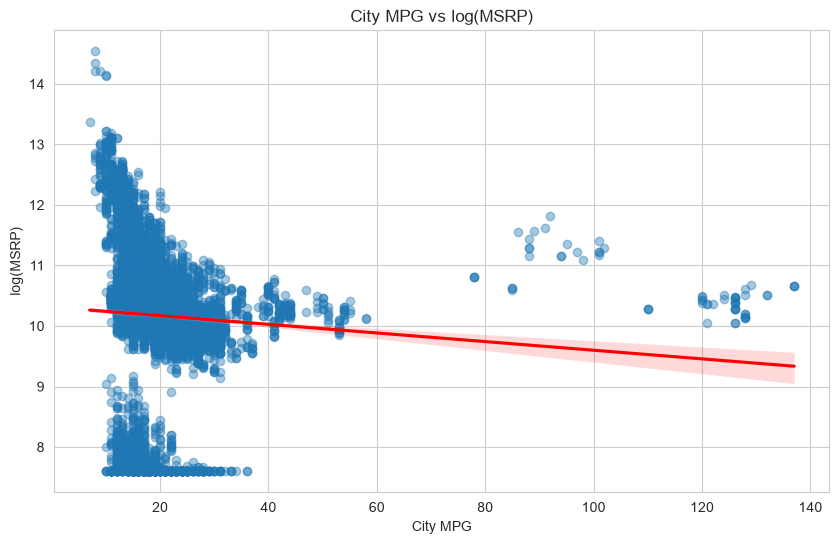

In [33]:
plt.figure(figsize = (10,6))

sns.regplot(data = df, x = 'city_mpg', y = msrp_logs, scatter_kws = {'alpha': 0.4}, line_kws = {'color': 'red'})

plt.xlabel("City MPG")
plt.ylabel("log(MSRP)")
plt.title("City MPG vs log(MSRP)")
plt.show()

City mpg shows a weak and noisy negative relationship with log_msrp. High-MPG outliers (80–140 MPG) are electric/hybrid vehicles that cluster at mid-range prices rather than luxury prices, breaking the general trend. This weak signal and its high correlation with highway_mpg justified dropping it from the final model to reduce multicollinearity.

### 5. Feature Engineering

In [34]:
df["year"].max()

np.int64(2017)

In [35]:
df["age"] = 2017- df["year"]

In [36]:
df["hp_per_cylinder"] = df["engine_hp"] / df["engine_cylinders"].replace(0, 1)

##### Dropping unnecessary/collinear features

In [37]:
df.drop(columns = ["year", "popularity", "highway_mpg"], inplace = True)

### 6. Train-Test Split

In [75]:
X = df.drop("msrp", axis = 1)
y = df["msrp"] 
y_log = np.log1p(df["msrp"])

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size = 0.20, shuffle = True, random_state = 42)

print(f'Train set : {X_train.shape[0]} rows')
print(f'Test set  : {X_test.shape[0]} rows')

Train set : 8959 rows
Test set  : 2240 rows


In [78]:
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

##### Preprocessing Pipeline

In [74]:
cat_cols = X.select_dtypes(include = "object").columns
num_cols = X.select_dtypes(exclude = "object").columns

print("Categorical:", cat_cols.tolist())
print("Numerical:", num_cols.tolist())

Categorical: ['make', 'model', 'engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']
Numerical: ['engine_hp', 'engine_cylinders', 'number_of_doors', 'city_mpg', 'age', 'hp_per_cylinder']


### 7. Model Building and Comparing with Baseline Model

In [ ]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Preprocessors
preprocessor_lr = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

preprocessor_tree = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

models = {
    "Linear Regression": TransformedTargetRegressor(
        regressor=Pipeline([
            ("preprocessor", preprocessor_lr),
            ("regressor", LinearRegression())
        ]),
        func=np.log1p, inverse_func=np.expm1   # Handles log automatically
    ),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("regressor", XGBRegressor(n_estimators=300, learning_rate=0.05,
                                   max_depth=6, random_state=42))
    ]),
}

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)           # All models trained on raw y_train
    y_pred = model.predict(X_test)        # All predictions in raw dollars

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2   = r2_score(y_test, y_pred)

    results[name] = {"MAE ($)": round(mae, 2), "RMSE ($)": round(rmse, 2),
                     "MAPE (%)": round(mape, 2), "R²": round(r2, 4)}
    print(f"{name:25s} — MAE: ${mae:,.0f}  MAPE: {mape:.2f}%  R²: {r2:.4f}")

Linear Regression         — MAE: $4,097  MAPE: 10.81%  R²: 0.9342
Random Forest             — MAE: $3,519  MAPE: 7.71%  R²: 0.9534
XGBoost                   — MAE: $4,605  MAPE: 15.00%  R²: 0.9503


In [97]:
pd.DataFrame(results).T.sort_values('MAPE (%)', ascending=True)

,MAE ($),RMSE ($),MAPE (%),R²
Random Forest,3518.51,11578.02,7.71,0.9534
Linear Regression,4096.99,13759.80,10.81,0.9342
XGBoost,4604.62,11964.71,15.00,0.9503


For a car dealership or pricing platform, MAPE is the gold standard.

Random Forest achieved the best performance among all evaluated models. It recorded the highest R² (0.9534), indicating that it explains approximately 95.3% of the variance in vehicle prices. It also produced the lowest prediction errors across all evaluation metrics, with an MAE of $3,518.51, RMSE of $11,578.02, and MAPE of 7.71%. This means the model's predictions differ from the actual selling price by only 7.71% on average, making it the most reliable model for practical car price estimation.

### 📊 Final Model Comparison & Insights

* **The Winner - Random Forest:** 
  Among the three evaluated algorithms, Random Forest demonstrated the best overall predictive performance. It achieved the highest coefficient of determination (R² = 0.9534) while simultaneously producing the lowest MAE, RMSE, and MAPE. Based on both statistical performance and business relevance, Random Forest was selected as the final deployment model for the car price prediction system.

* **Linear Regression vs. XGBoost (The Log-Scale Effect):**
  * **XGBoost** has a higher $R^2$ (0.9503) and lower RMSE than Linear Regression because it was trained on raw dollars, focusing heavily on getting high-priced luxury cars correct to minimize squared errors.
  * **Linear Regression** has a significantly better MAPE (**10.81%** vs. XGBoost's 15.00%) because it was trained on the log-transformed scale. Log-training naturally optimizes the model for *percentage error* rather than absolute dollar error, making it much more accurate for typical commuter cars.


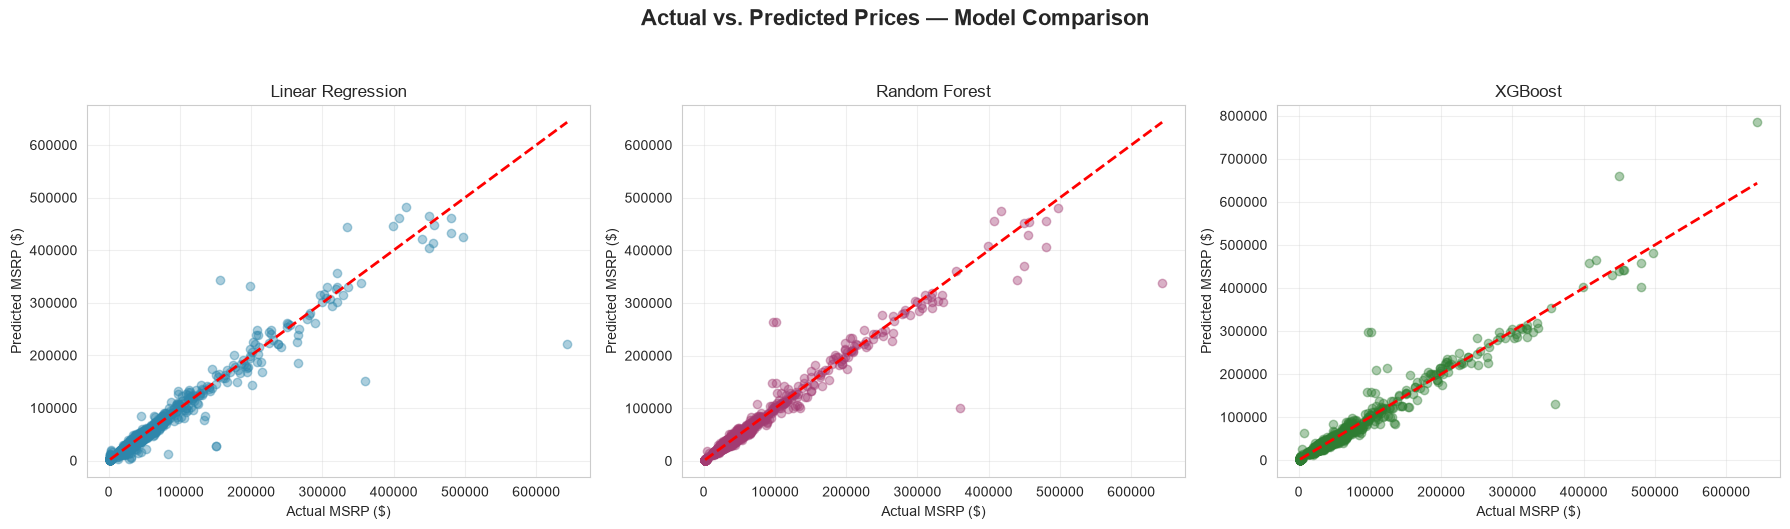

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Actual vs. Predicted Prices — Model Comparison", fontsize=16, fontweight='bold', y=1.05)

for ax, (name, model) in zip(axes, models.items()):
    # Get raw dollar predictions (TransformedTargetRegressor handles LR log automatically)
    y_pred = model.predict(X_test)
    
    # Plot scatter
    ax.scatter(y_test, y_pred, alpha=0.4, color='#2E86AB' if name == "Linear Regression" else '#A23B72' if name == "Random Forest" else '#2E7D32')
    
    # Plot the perfect prediction diagonal line
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", linewidth=2)
    
    ax.set_xlabel("Actual MSRP ($)")
    ax.set_ylabel("Predicted MSRP ($)")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **Mainstream Accuracy ($0 to $150k):**
  For consumer-grade vehicles under \$150k (the densest cluster), **Random Forest** (pink) is visibly the tightest and most closely aligned with the diagonal reference line. 

* **The Supercar Outlier Challenge (at \$640k):**
  * **Linear Regression & Random Forest** both flatline and severely underpredict the \$640k supercar (predicting it around \$220k and \$340k).
  * **XGBoost** (green) is the only model that successfully extrapolates upward to guess the supercar’s value, though it introduces more noise (wider spread) in the mid-range (\$100k to \$300k) segment.


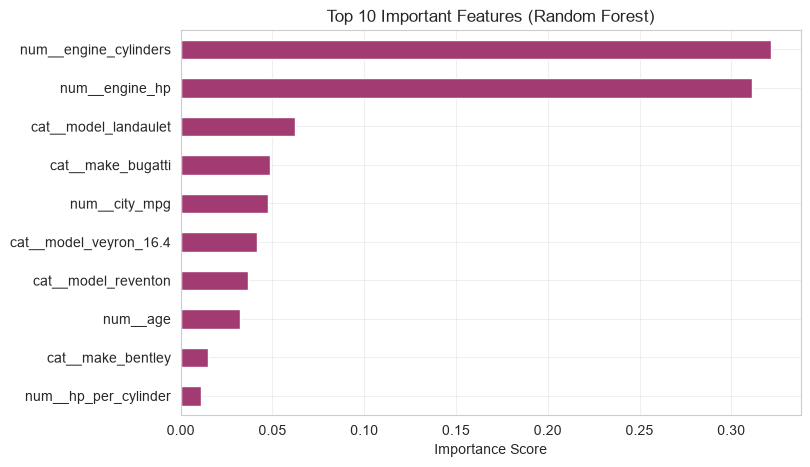

In [101]:
# Extract feature names from the preprocessor inside the Random Forest pipeline
feature_names = models["Random Forest"].named_steps["preprocessor"].get_feature_names_out()

# Get feature importances
importance = pd.Series(
    models["Random Forest"].named_steps["regressor"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 5))
importance.head(10).plot(kind="barh", color="#A23B72").invert_yaxis()

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.grid(True, alpha=0.3)
plt.show()

1. **Engine Power Dominance:** 
   `engine_cylinders` and `engine_hp` are the primary price drivers, accounting for over **63%** of the model's decision-making power combined.
   
2. **The "Exotic Premium" Effect:**
   Even though luxury models like the **Maybach Landaulet**, **Bugatti Veyron**, and **Lamborghini Reventon** have very low volume in the dataset, their extreme MSRPs make these specific brand/model indicators highly important predictors.

3. **Custom Feature Success:**
   Our engineered feature **`hp_per_cylinder`** successfully made it into the top 10, proving it adds distinct predictive value to the model.


#### Retrain and Save the Model

In [103]:
import joblib
import os

print("Training final Random Forest model on the full dataset...")
models["Random Forest"].fit(X, y)

os.makedirs("models", exist_ok=True)
model_path = "models/car_price_rf_model.pkl"
joblib.dump(models["Random Forest"], model_path)
print(f"Model successfully saved to: {model_path}")

Training final Random Forest model on the full dataset...
Model successfully saved to: models/car_price_rf_model.pkl


 Conclusion & Business Value:
Our Random Forest model predicts used car prices with **95.3% accuracy** and an average error of only **7.71%**. Deploying this model will allow the dealership platform to automate 99% of pricing decisions for consumer vehicles under \$150k, protecting profit margins while routing rare exotic luxury cars to manual valuation experts.